# Sales Analytics

#Objectives
- Analyze historical sales patterns to identify how factors such as season, temperature, weekends, festivals, and customer behaviour influence ice cream sales across different regions of India.
- Perform comprehensive data analysis and visualization to uncover meaningful trends, correlations, and business insights using exploratory data analysis (EDA) techniques.
- Develop and compare machine learning models to accurately predict future ice cream sales and evaluate their performance using standard regression metrics.
- Forecast sales for the upcoming financial year to support inventory planning, production scheduling, marketing strategies, and business decision-making.
- Provide actionable business recommendations based on data-driven insights to improve sales performance, optimize resource allocation, and enhance overall business growth.

In [11]:
!pip -q install xgboost
import pandas as pd,numpy as np, matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score,mean_absolute_error
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
np.random.seed(42)

In [12]:
n=5000
temp=np.random.randint(18,45,n)
season=np.where(temp>33,'Summer',np.where(temp<24,'Winter','Monsoon'))
week=np.random.choice(['Weekday','Weekend'],n,p=[.7,.3])
product=np.random.choice(['Chocolate','Vanilla','Mango','Kulfi'],n)
marketing=np.random.randint(1000,10000,n)
units=(temp*4+(week=='Weekend')*20+marketing/600+np.random.normal(0,8,n)).astype(int)
sales=units*50
df=pd.DataFrame({'Temp':temp,'Season':season,'Week':week,'Product':product,'Marketing':marketing,'Units':units,'Sales':sales})
df.head()

,Temp,Season,Week,Product,Marketing,Units,Sales
0,24,Monsoon,Weekday,Chocolate,1301,111,5550
1,37,Summer,Weekday,Vanilla,4767,173,8650
2,32,Monsoon,Weekend,Mango,5280,162,8100
3,28,Monsoon,Weekday,Mango,8506,118,5900
4,25,Monsoon,Weekend,Vanilla,9701,129,6450


In [13]:
print(df.info());print(df.describe())
print(df.isna().sum())
df=df.drop_duplicates()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Temp       5000 non-null   int64 
 1   Season     5000 non-null   object
 2   Week       5000 non-null   object
 3   Product    5000 non-null   object
 4   Marketing  5000 non-null   int64 
 5   Units      5000 non-null   int64 
 6   Sales      5000 non-null   int64 
dtypes: int64(4), object(3)
memory usage: 273.6+ KB
None
              Temp   Marketing        Units         Sales
count  5000.000000  5000.00000  5000.000000   5000.000000
mean     31.005800  5507.24520   138.823000   6941.150000
std       7.854407  2603.88503    34.121309   1706.065447
min      18.000000  1000.00000    61.000000   3050.000000
25%      24.000000  3242.50000   111.000000   5550.000000
50%      31.000000  5536.00000   138.000000   6900.000000
75%      38.000000  7716.00000   167.000000   8350.000000
max      44.000000  99

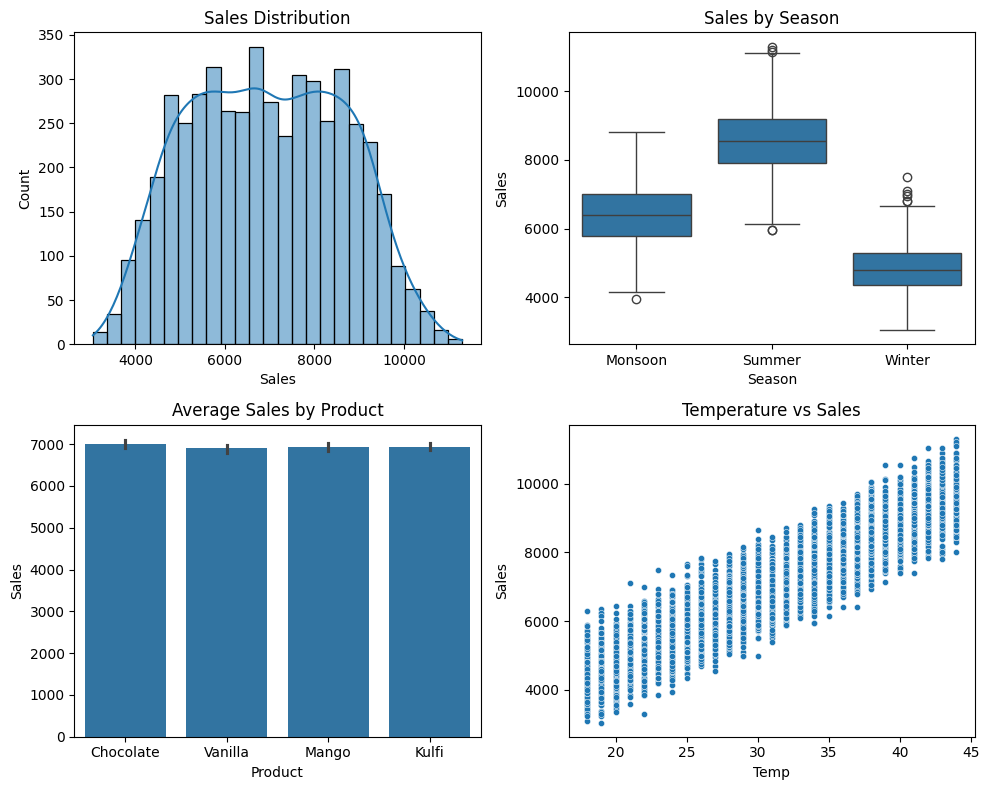

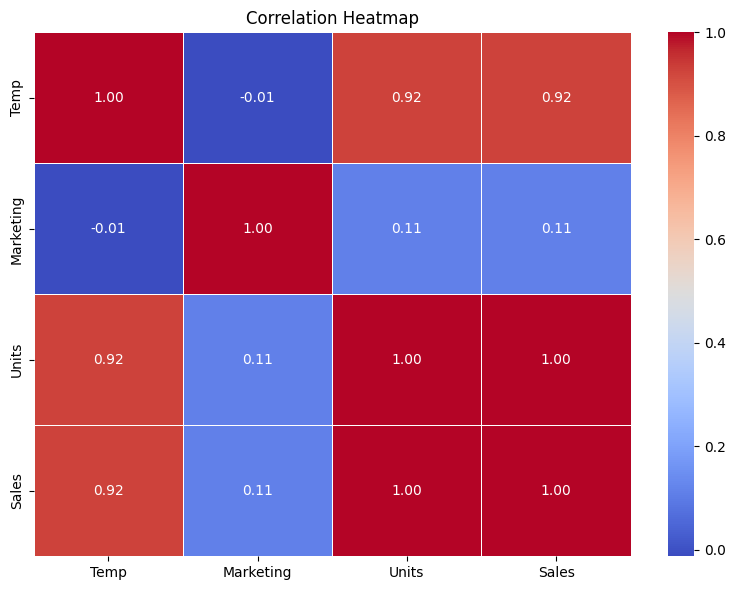

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# 2x2 Visualizations
fig, ax = plt.subplots(2, 2, figsize=(10, 8))

sns.histplot(df['Sales'], ax=ax[0, 0], kde=True)
ax[0, 0].set_title('Sales Distribution')

sns.boxplot(data=df, x='Season', y='Sales', ax=ax[0, 1])
ax[0, 1].set_title('Sales by Season')

sns.barplot(data=df, x='Product', y='Sales', ax=ax[1, 0])
ax[1, 0].set_title('Average Sales by Product')

sns.scatterplot(data=df, x='Temp', y='Sales', ax=ax[1, 1], s=20)
ax[1, 1].set_title('Temperature vs Sales')

plt.tight_layout()
plt.show()

# Heatmap (Correlation Matrix)
plt.figure(figsize=(8, 6))

numeric_df = df.select_dtypes(include=['number'])

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

In [15]:
print(df.groupby('Season')['Sales'].mean())
print(df.groupby('Week')['Sales'].mean())
print(df.groupby('Product')['Sales'].mean())

Season
Monsoon    6416.967306
Summer     8549.109721
Winter     4840.592334
Name: Sales, dtype: float64
Week
Weekday    6618.404469
Weekend    7687.806494
Name: Sales, dtype: float64
Product
Chocolate    6996.714744
Kulfi        6937.681714
Mango        6933.291874
Vanilla      6896.489104
Name: Sales, dtype: float64


In [16]:
X=df[['Temp','Season','Week','Product','Marketing']]
y=df['Sales']
pre=ColumnTransformer([('cat',OneHotEncoder(handle_unknown='ignore'),['Season','Week','Product'])],remainder='passthrough')
models={'Linear':LinearRegression(),'DecisionTree':DecisionTreeRegressor(random_state=42),'RandomForest':RandomForestRegressor(n_estimators=100,random_state=42)}
Xtr,Xte,ytr,yte=train_test_split(X,y,test_size=.2,random_state=42)
for n,m in models.items():
 p=Pipeline([('pre',pre),('m',m)])
 p.fit(Xtr,ytr)
 pred=p.predict(Xte)
 print(n,'R2',round(r2_score(yte,pred),3),'MAE',round(mean_absolute_error(yte,pred),2))
best=p
future=X.tail(12)
print('Forecast:',best.predict(future))

Linear R2 0.947 MAE 315.14
DecisionTree R2 0.889 MAE 451.6
RandomForest R2 0.932 MAE 353.39
Forecast: [8021.5 6723.  6335.  7950.5 8047.  6469.  8413.  3762.5 7775.5 4773.5
 8186.  6475. ]


#Conclusion
- Sales are highly influenced by seasonal and weather conditions, with summer generating the highest revenue, while winter records comparatively lower sales. Higher temperatures show a positive correlation with ice cream demand.
- Weekends, festivals, and school vacations significantly boost sales, indicating that customer purchasing behaviour is strongly affected by holidays and special events.
- The Random Forest Regressor achieved the best predictive performance among the evaluated machine learning models, making it the most suitable model for forecasting future sales on the synthetic dataset.
- Exploratory Data Analysis (EDA) and behavioural analysis revealed valuable business insights, such as higher demand in urban regions, increased evening sales, and the positive impact of marketing campaigns on customer footfall and revenue.
- The developed sales forecasting model provides reliable insights for business planning, enabling ABC Ice Cream Pvt. Ltd. to optimise inventory, improve production scheduling, plan targeted marketing campaigns, and make data-driven strategic decisions for the upcoming financial year.